In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

conn   = sqlite3.connect('olist_database.db')
engine = create_engine('sqlite:///olist_database.db')

print("Connected to olist_database.db ✓")

Connected to olist_database.db ✓


In [2]:
# Products table needs to be in the database for SQL joins
products    = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

products_merged = products.merge(translation, on='product_category_name', how='left')

# Fix 2 unmatched categories
manual_map = {
    'pc_gamer': 'pc_gamer',
    'portateis_cozinha_e_preparadores_de_alimentos': 'portable_kitchen_food_preparers'
}
products_merged['product_category_name_english'] = products_merged.apply(
    lambda row: manual_map.get(row['product_category_name'], row['product_category_name_english'])
    if pd.isnull(row['product_category_name_english']) else row['product_category_name_english'],
    axis=1
)
products_merged['product_category_name_english'] = (
    products_merged['product_category_name_english']
    .str.lower().str.strip().str.replace(' ', '_', regex=False)
)

products_merged.to_sql('products', conn, if_exists='replace', index=False)
print("products table loaded ✓")
print("Rows:", len(products_merged))

products table loaded ✓
Rows: 32951


In [3]:
customers = pd.read_csv('olist_customers_dataset.csv')
customers.to_sql('customers', conn, if_exists='replace', index=False)
print("customers table loaded ✓")
print("States available:", customers['customer_state'].nunique(), "states")

customers table loaded ✓
States available: 27 states


In [4]:
# Preview all 4 tables we'll be joining
print("orders columns    :", pd.read_sql("SELECT * FROM orders LIMIT 1", conn).columns.tolist())
print("order_items cols  :", pd.read_sql("SELECT * FROM order_items LIMIT 1", conn).columns.tolist())
print("customers columns :", pd.read_sql("SELECT * FROM customers LIMIT 1", conn).columns.tolist())
print("products columns  :", pd.read_sql("SELECT * FROM products LIMIT 1", conn).columns.tolist())

orders columns    : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_items cols  : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
customers columns : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
products columns  : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


In [5]:
base_query = '''
    SELECT
        c.customer_state                            AS state,
        p.product_category_name_english             AS category,
        COUNT(DISTINCT o.order_id)                  AS total_orders,
        ROUND(SUM(oi.price), 2)                     AS total_revenue,
        ROUND(AVG(oi.price), 2)                     AS avg_price
    FROM orders o
    JOIN order_items oi  ON o.order_id   = oi.order_id
    JOIN customers c     ON o.customer_id = c.customer_id
    JOIN products p      ON oi.product_id = p.product_id
    WHERE
        o.order_status = 'delivered'
        AND p.product_category_name_english IS NOT NULL
    GROUP BY
        c.customer_state,
        p.product_category_name_english
    ORDER BY
        c.customer_state,
        total_revenue DESC
'''

base_df = pd.read_sql_query(base_query, conn)
print("Total state-category combinations:", len(base_df))
print("\nSample output:")
print(base_df.head(10).to_string(index=False))

Total state-category combinations: 1362

Sample output:
state               category  total_orders  total_revenue  avg_price
   AC         sports_leisure             9        1677.46     186.38
   AC          watches_gifts             4        1389.60     347.40
   AC          health_beauty             6        1386.58     198.08
   AC        furniture_decor             7        1316.44     109.70
   AC  computers_accessories             6        1238.50     154.81
   AC              computers             1        1200.00    1200.00
   AC              telephony             5        1103.96     220.79
   AC                   baby             3         697.84     232.61
   AC books_general_interest             2         633.80     316.90
   AC           garden_tools             2         629.00     314.50


In [6]:
ranking_query = '''
    WITH state_category_sales AS (
        SELECT
            c.customer_state                        AS state,
            p.product_category_name_english         AS category,
            COUNT(DISTINCT o.order_id)              AS total_orders,
            ROUND(SUM(oi.price), 2)                 AS total_revenue
        FROM orders o
        JOIN order_items oi  ON o.order_id    = oi.order_id
        JOIN customers c     ON o.customer_id  = c.customer_id
        JOIN products p      ON oi.product_id  = p.product_id
        WHERE
            o.order_status = 'delivered'
            AND p.product_category_name_english IS NOT NULL
        GROUP BY
            c.customer_state,
            p.product_category_name_english
    )
    SELECT
        state,
        category,
        total_orders,
        total_revenue,
        RANK() OVER (
            PARTITION BY state
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM state_category_sales
    ORDER BY
        state,
        revenue_rank
'''

ranked_df = pd.read_sql_query(ranking_query, conn)
print("Full ranked output:")
print(ranked_df.head(30).to_string(index=False))

Full ranked output:
state                 category  total_orders  total_revenue  revenue_rank
   AC           sports_leisure             9        1677.46             1
   AC            watches_gifts             4        1389.60             2
   AC            health_beauty             6        1386.58             3
   AC          furniture_decor             7        1316.44             4
   AC    computers_accessories             6        1238.50             5
   AC                computers             1        1200.00             6
   AC                telephony             5        1103.96             7
   AC                     baby             3         697.84             8
   AC   books_general_interest             2         633.80             9
   AC             garden_tools             2         629.00            10
   AC           bed_bath_table             3         567.70            11
   AC                     auto             4         540.98            12
   AC             

In [7]:
top3_query = '''
    WITH state_category_sales AS (
        SELECT
            c.customer_state                        AS state,
            p.product_category_name_english         AS category,
            COUNT(DISTINCT o.order_id)              AS total_orders,
            ROUND(SUM(oi.price), 2)                 AS total_revenue
        FROM orders o
        JOIN order_items oi  ON o.order_id    = oi.order_id
        JOIN customers c     ON o.customer_id  = c.customer_id
        JOIN products p      ON oi.product_id  = p.product_id
        WHERE
            o.order_status = 'delivered'
            AND p.product_category_name_english IS NOT NULL
        GROUP BY
            c.customer_state,
            p.product_category_name_english
    ),
    ranked AS (
        SELECT
            state,
            category,
            total_orders,
            total_revenue,
            RANK() OVER (
                PARTITION BY state
                ORDER BY total_revenue DESC
            ) AS revenue_rank
        FROM state_category_sales
    )
    SELECT * FROM ranked
    WHERE revenue_rank <= 3
    ORDER BY state, revenue_rank
'''

top3_df = pd.read_sql_query(top3_query, conn)
print(f"States covered: {top3_df['state'].nunique()}")
print(f"Total rows (3 per state): {len(top3_df)}")
print("\nTop 3 categories per state:")
print(top3_df.to_string(index=False))

States covered: 27
Total rows (3 per state): 81

Top 3 categories per state:
state              category  total_orders  total_revenue  revenue_rank
   AC        sports_leisure             9        1677.46             1
   AC         watches_gifts             4        1389.60             2
   AC         health_beauty             6        1386.58             3
   AL         health_beauty            62       12681.26             1
   AL         watches_gifts            34       11605.02             2
   AL computers_accessories            32        7605.61             3
   AM         health_beauty            15        2776.03             1
   AM          garden_tools             5        1980.88             2
   AM computers_accessories            10        1815.74             3
   AP computers_accessories             6        2050.03             1
   AP         watches_gifts             7        1639.80             2
   AP             computers             1        1437.00             3


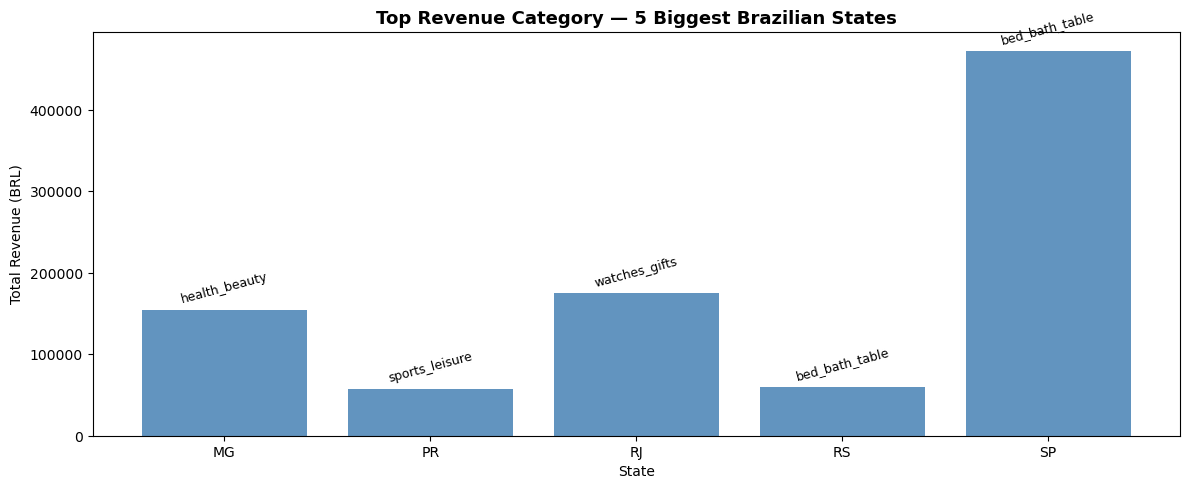

In [8]:
big_states  = ['SP', 'RJ', 'MG', 'RS', 'PR']
top1_states = top3_df[
    (top3_df['state'].isin(big_states)) &
    (top3_df['revenue_rank'] == 1)
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top1_states['state'], top1_states['total_revenue'], color='steelblue', alpha=0.85)

# Label each bar with category name
for bar, (_, row) in zip(bars, top1_states.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            row['category'],
            ha='center', va='bottom', fontsize=9, rotation=15)

ax.set_title('Top Revenue Category — 5 Biggest Brazilian States', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

In [9]:
state_summary_query = '''
    SELECT
        c.customer_state                            AS state,
        COUNT(DISTINCT o.order_id)                  AS total_orders,
        COUNT(DISTINCT p.product_category_name_english) AS unique_categories,
        ROUND(SUM(oi.price), 2)                     AS total_revenue,
        ROUND(AVG(oi.price), 2)                     AS avg_order_value,
        ROUND(SUM(oi.price) * 100.0 /
            SUM(SUM(oi.price)) OVER (), 2)          AS revenue_share_pct
    FROM orders o
    JOIN order_items oi  ON o.order_id    = oi.order_id
    JOIN customers c     ON o.customer_id  = c.customer_id
    JOIN products p      ON oi.product_id  = p.product_id
    WHERE
        o.order_status = 'delivered'
        AND p.product_category_name_english IS NOT NULL
    GROUP BY
        c.customer_state
    ORDER BY
        total_revenue DESC
'''

state_summary = pd.read_sql_query(state_summary_query, conn)
print("=== State Level Summary ===")
print(state_summary.to_string(index=False))

=== State Level Summary ===
state  total_orders  unique_categories  total_revenue  avg_order_value  revenue_share_pct
   SP         39963                 72     5004752.07           109.22              38.35
   RJ         12168                 70     1736924.95           124.68              13.31
   MG         11190                 70     1534496.09           120.48              11.76
   RS          5270                 67      721001.86           119.37               5.52
   PR          4855                 64      657744.28           118.04               5.04
   SC          3491                 64      500030.47           123.86               3.83
   BA          3215                 62      487660.19           134.53               3.74
   DF          2050                 60      293919.59           126.53               2.25
   GO          1911                 62      274306.59           123.28               2.10
   ES          1978                 58      267029.18           120.99  

In [10]:
category_summary_query = '''
    SELECT
        p.product_category_name_english             AS category,
        COUNT(DISTINCT c.customer_state)            AS states_present_in,
        COUNT(DISTINCT o.order_id)                  AS total_orders,
        ROUND(SUM(oi.price), 2)                     AS total_revenue,
        ROUND(AVG(oi.price), 2)                     AS avg_price,
        ROUND(SUM(oi.price) * 100.0 /
            SUM(SUM(oi.price)) OVER (), 2)          AS revenue_share_pct
    FROM orders o
    JOIN order_items oi  ON o.order_id    = oi.order_id
    JOIN customers c     ON o.customer_id  = c.customer_id
    JOIN products p      ON oi.product_id  = p.product_id
    WHERE
        o.order_status = 'delivered'
        AND p.product_category_name_english IS NOT NULL
    GROUP BY
        p.product_category_name_english
    ORDER BY
        total_revenue DESC
    LIMIT 15
'''

category_summary = pd.read_sql_query(category_summary_query, conn)
print("=== Top 15 Categories Nationwide ===")
print(category_summary.to_string(index=False))

=== Top 15 Categories Nationwide ===
             category  states_present_in  total_orders  total_revenue  avg_price  revenue_share_pct
        health_beauty                 27          8647     1233131.72     130.28               9.45
        watches_gifts                 27          5495     1166176.98     199.04               8.94
       bed_bath_table                 27          9272     1023434.76      93.44               7.84
       sports_leisure                 27          7530      954852.55     113.25               7.32
computers_accessories                 27          6530      888724.61     116.26               6.81
      furniture_decor                 27          6307      711927.69      87.25               5.46
           housewares                 26          5743      615628.69      90.60               4.72
           cool_stuff                 27          3559      610204.10     164.12               4.68
                 auto                 27          3810      578